In [18]:
import pandas as pd

df = pd.read_csv("../data/raw/globalmech_data.csv", 
                 parse_dates=["Date"], 
                 index_col="Date")

df.head()

,Dom_Cap,Dom_Spares,Exp_Cap,Exp_Spares,Install_Base,USD_INR,Shipping_Index
Date,,,,,,,
2019-01-01,147.825430,191.370853,105.696490,273.283568,509,70.448357,49.820870
2019-02-01,152.360103,163.677497,95.153384,299.331394,518,70.579225,57.823218
2019-03-01,156.791872,170.055367,101.755957,279.249202,529,71.103069,36.901274
2019-04-01,158.202817,165.563635,102.600079,282.528339,542,72.064584,54.109513
2019-05-01,143.930276,189.948716,103.405069,306.987159,555,72.147507,50.435235


In [19]:
df_fe = df.copy()

# Lag features
for col in ["Dom_Cap", "Dom_Spares", "Exp_Cap", "Exp_Spares"]:
    df_fe[f"{col}_lag1"] = df_fe[col].shift(1)
    df_fe[f"{col}_lag3"] = df_fe[col].shift(3)

# Rolling mean
for col in ["Dom_Cap", "Dom_Spares"]:
    df_fe[f"{col}_roll3"] = df_fe[col].rolling(3).mean()

# Time features
df_fe["month"] = df_fe.index.month
df_fe["quarter"] = df_fe.index.quarter

df_fe.dropna(inplace=True)

df_fe.head()

,Dom_Cap,Dom_Spares,Exp_Cap,Exp_Spares,Install_Base,USD_INR,Shipping_Index,Dom_Cap_lag1,Dom_Cap_lag3,Dom_Spares_lag1,Dom_Spares_lag3,Exp_Cap_lag1,Exp_Cap_lag3,Exp_Spares_lag1,Exp_Spares_lag3,Dom_Cap_roll3,Dom_Spares_roll3,month,quarter
Date,,,,,,,,,,,,,,,,,,,
2019-04-01,158.202817,165.563635,102.600079,282.528339,542,72.064584,54.109513,156.791872,147.825430,170.055367,191.370853,101.755957,105.696490,279.249202,273.283568,155.784931,166.432166,4,2
2019-05-01,143.930276,189.948716,103.405069,306.987159,555,72.147507,50.435235,158.202817,152.360103,165.563635,163.677497,102.600079,95.153384,282.528339,299.331394,152.974988,175.189239,5,2
2019-06-01,162.883197,179.228000,112.460127,293.976687,562,72.230439,48.504963,143.930276,156.791872,189.948716,170.055367,103.405069,101.755957,306.987159,279.249202,155.005430,178.246783,6,2
2019-07-01,173.639354,185.682114,118.176482,279.025963,569,73.220045,50.458804,162.883197,158.202817,179.228000,165.563635,112.460127,102.600079,293.976687,282.528339,160.150942,184.952943,7,3
2019-08-01,156.434622,208.979137,102.256007,311.947081,576,73.803763,40.062155,173.639354,143.930276,185.682114,189.948716,118.176482,103.405069,279.025963,306.987159,164.319058,191.296417,8,3


* Added memory (lags)
* Added trend smoothing
* Added seasonality signals

<h4>STEP 1 — Prepare Features & Targets

In [20]:
targets = ["Dom_Cap", "Dom_Spares", "Exp_Cap", "Exp_Spares"]

X = df_fe.drop(columns=targets)
y = df_fe[targets]

<h4>STEP 2 — Train/Test Split (TIME SERIES)

In [21]:
split = int(len(df_fe) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

<h4>STEP 3 — MULTI-OUTPUT XGBOOST</h4>

XGBoost doesn’t directly support multi-output → we wrap it

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

base_model = RandomForestRegressor(n_estimators=200, random_state=42)

model = MultiOutputRegressor(base_model)
model.fit(X_train, y_train)

preds = model.predict(X_test)

<h4>STEP 4 — Evaluation (FOR ALL TARGETS)

In [23]:
from sklearn.metrics import mean_absolute_error
import numpy as np

for i, col in enumerate(targets):
    mae = mean_absolute_error(y_test[col], preds[:, i])
    print(f"{col} MAE:", mae)

Dom_Cap MAE: 14.279692993145435
Dom_Spares MAE: 17.818977091243532
Exp_Cap MAE: 19.90873027049519
Exp_Spares MAE: 25.398576781663536


<h4>STEP 5 — Visualization

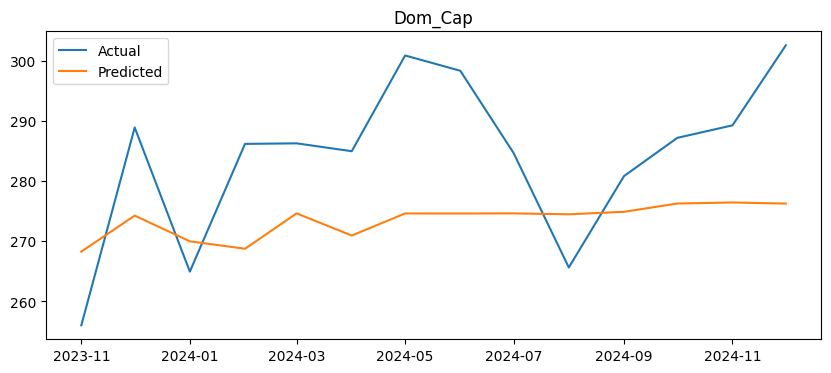

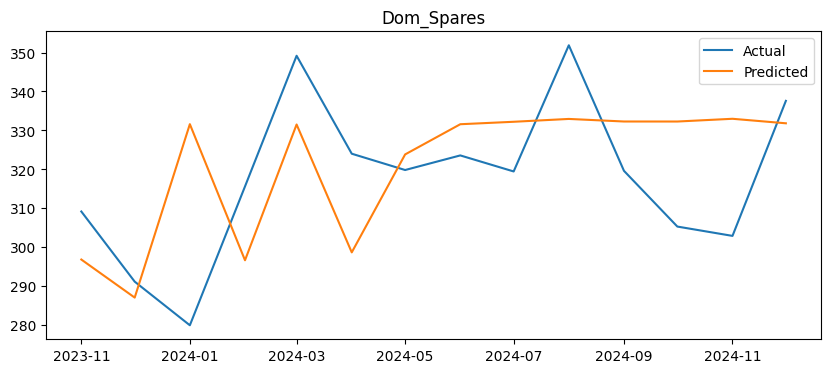

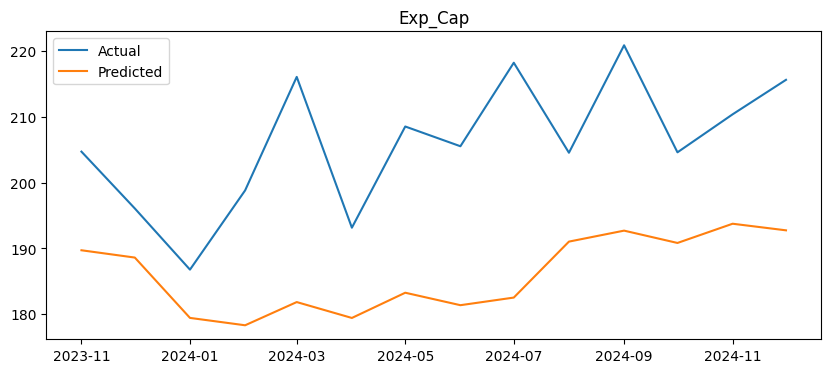

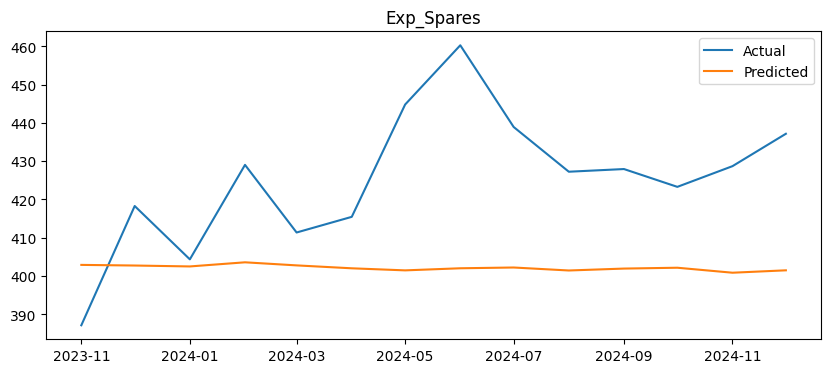

In [24]:
import matplotlib.pyplot as plt

for i, col in enumerate(targets):
    plt.figure(figsize=(10,4))
    plt.plot(y_test.index, y_test[col], label="Actual")
    plt.plot(y_test.index, preds[:, i], label="Predicted")
    plt.title(col)
    plt.legend()
    plt.show()

<h2>SCENARIO SIMULATION ENGINE</h2>
“What if USD increases?”


“What if install base grows?”


“What if shipping delays worsen?”


model responds with new revenue forecasts

<h4>1. Create Scenario Function

In [25]:
def simulate_scenario(model, X_base, usd_change=0, install_change=0, shipping_change=0):
    
    X_sim = X_base.copy()
    
    # Apply changes
    X_sim["USD_INR"] += usd_change
    X_sim["Install_Base"] += install_change
    X_sim["Shipping_Index"] += shipping_change
    
    preds = model.predict(X_sim)
    
    return preds

<h4>Run Scenario

In [26]:
# Take latest data point
latest_X = X_test.tail(1)

# Simulate scenario
scenario_preds = simulate_scenario(
    model,
    latest_X,
    usd_change=5,          # USD increases
    install_change=50,     # more machines installed
    shipping_change=10     # delays increase
)

print(scenario_preds)

[[276.2216114  331.75718788 191.14492245 399.51827128]]


<h4> Compare Before vs After

In [27]:
baseline = model.predict(latest_X)

for i, col in enumerate(["Dom_Cap", "Dom_Spares", "Exp_Cap", "Exp_Spares"]):
    print(f"{col}:")
    print("Before:", baseline[0][i])
    print("After :", scenario_preds[0][i])
    print("Change:", scenario_preds[0][i] - baseline[0][i])
    print("-" * 30)

Dom_Cap:
Before: 276.2366681863839
After : 276.2216113973018
Change: -0.01505678908210939
------------------------------
Dom_Spares:
Before: 331.81286335365604
After : 331.75718788312275
Change: -0.05567547053328781
------------------------------
Exp_Cap:
Before: 192.7289591193096
After : 191.14492245170072
Change: -1.5840366676088706
------------------------------
Exp_Spares:
Before: 401.474567426537
After : 399.5182712831657
Change: -1.9562961433713326
------------------------------


In [28]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']